In [ ]:
import pickle
with open("pre_split_data.pkl", "rb") as f:
    X, y, categorical, numerical = pickle.load(f)

# Segmentation model
We aim to cluster the data and infer group characteristics.\
We choose K-Means clustering in combination with dimension reduction using TruncatedSVD. 

### We first encode categorical data iusing frequency encoding and scale all data using standard scaler

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import silhouette_score

# use frequency encoding 
X_enc = X.copy()
for col in categorical:
    freq = X_enc[col].value_counts() / len(X_enc)
    X_enc[col] = X_enc[col].map(freq)
# scale numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_enc)
X_enc = pd.DataFrame(X_scaled, columns=X_enc.columns, index = X_enc.index)

In [64]:
# features with very low variance does not contribute to clustering, remove if any
selector = VarianceThreshold(threshold=0.01)
X_filtered = selector.fit_transform(X_enc)
remaining_columns = X_enc.columns[selector.get_support()]
dropped_columns = X_enc.columns[~selector.get_support()]
print('dropped columns: ',dropped_columns)

dropped columns:  Index([], dtype='object')


### Run a K-Means directly on scaled data.

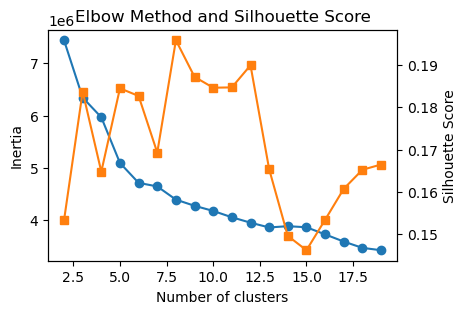

In [ ]:
def optimize_k(X_scaled):
    # given scaled data, fit a number KMeans and plot the inertia
    # need to interpret the figure to find optimal k
    inertia = []
    silhouette = []
    K = range(2, 20)
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=27)
        clusters = kmeans.fit_predict(X_scaled)
        inertia.append(kmeans.inertia_)
        sample_idx = np.random.choice(len(X_scaled), size=8000, replace=False)
        silhouette.append(silhouette_score(X_scaled[sample_idx], clusters[sample_idx]))

    fig, ax1 = plt.subplots(figsize=(4.5,3))

    # Inertia (left axis)
    ax1.plot(K, inertia, marker='o')
    ax1.set_xlabel("Number of clusters")
    ax1.set_ylabel("Inertia")
    ax1.set_title("Elbow Method and Silhouette Score")
    # Silhouette (right axis)
    ax2 = ax1.twinx()
    ax2.plot(K, silhouette, marker='s', color='#ff7f0e')
    ax2.set_ylabel("Silhouette Score")

    plt.show()

optimize_k(X_filtered)

looking for a high silhouette value in the elbow redion of inertia, we find k= 8 to be a good nubmer of cluster value.

### Now we attempt a PCA dimension reduction, hoping to improve the silhouette score

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.90)  # keep 90% variance
X_pca = pca.fit_transform(X_filtered)
print(X_pca.shape) # we end up with 21 features instead of 41

(196294, 21)


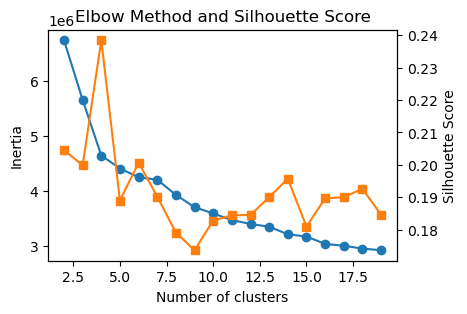

In [84]:
optimize_k(X_pca)

With PCA, we find that k = 3 to be a good number of clusters with a much higher silhouette score. \
Given the cluster labels, we group data by their cluster. \
We can calculate the mean values on the numerical columns.

In [85]:
kmeans = KMeans(n_clusters=3, random_state=27)
clusters = kmeans.fit_predict(X_pca)
X['cluster'] = clusters

In [86]:
# need a different split of num vs cat

numerical_summary  = X.groupby('cluster')[numerical].mean()
print(numerical_summary)

               age  detailed industry recode  detailed occupation recode  \
cluster                                                                    
0        38.866371                 16.748022                   14.468785   
1        38.681741                 31.163244                   22.402329   
2        30.244461                  0.000843                    0.000729   

         wage per hour       sex  member of a labor union  capital gains  \
cluster                                                                    
0            48.202387  0.471498                -0.059446     405.721306   
1           115.661554  0.519655                -0.135279     795.544553   
2             0.000000  0.439389                 0.000000     102.901437   

         capital losses  dividends from stocks       weight  \
cluster                                                       
0             33.652412             105.630442  1537.054867   
1             63.605762             232.809080  1

In [87]:
X['cluster'].value_counts()

cluster
2    87781
1    86392
0    22121
Name: count, dtype: int64

numerical features, year doesn't matter, reduce to 16 features, plot 6 bars one for each cluster. 
Each subplot is one feature

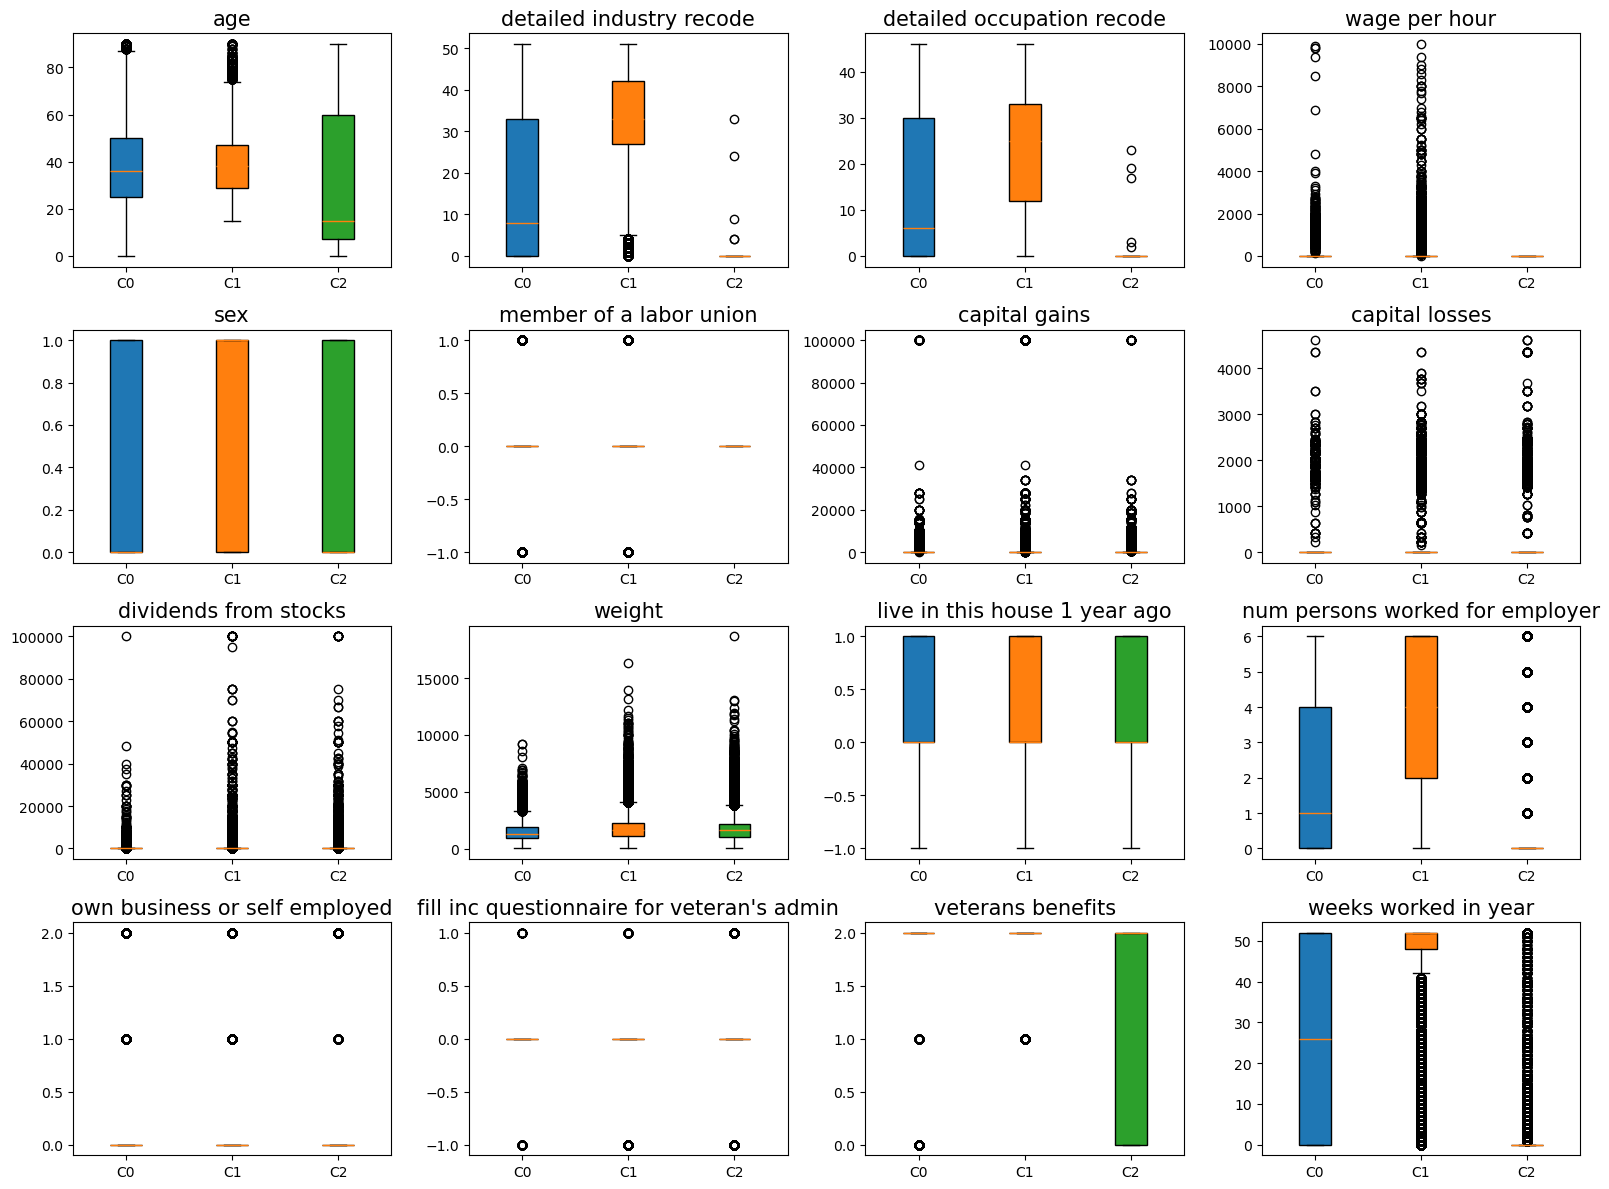

In [96]:
features = numerical_summary.drop(columns=['year']).columns
n_clusters = len(np.unique(clusters))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']

fig, axes = plt.subplots(4, 4, figsize=(16,12))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    data_per_cluster = [X[feature][clusters == c] for c in range(n_clusters)]
    bp = ax.boxplot(data_per_cluster, patch_artist=True)
    for patch, color in zip(bp['boxes'], colors[:n_clusters]):
        patch.set_facecolor(color)
    
    ax.set_title(feature, fontsize=15)
    ax.set_xticks(np.arange(1, n_clusters+1))
    ax.set_xticklabels([f"C{c}" for c in range(n_clusters)])
    
plt.tight_layout()
plt.show()

Ctegorical features can will be plotted separately as heatmaps, each has value * cluster

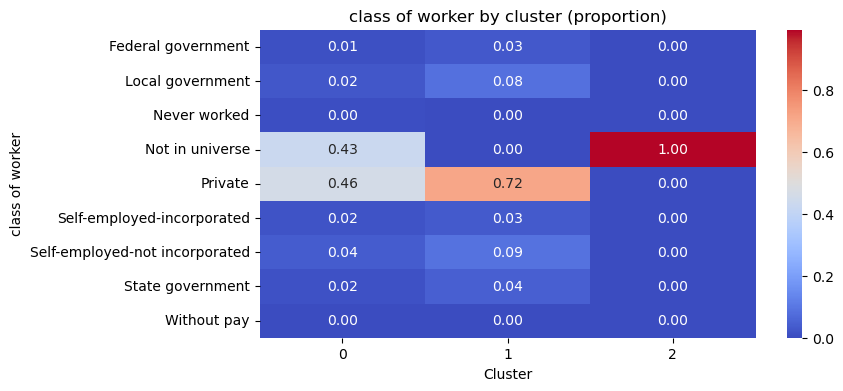

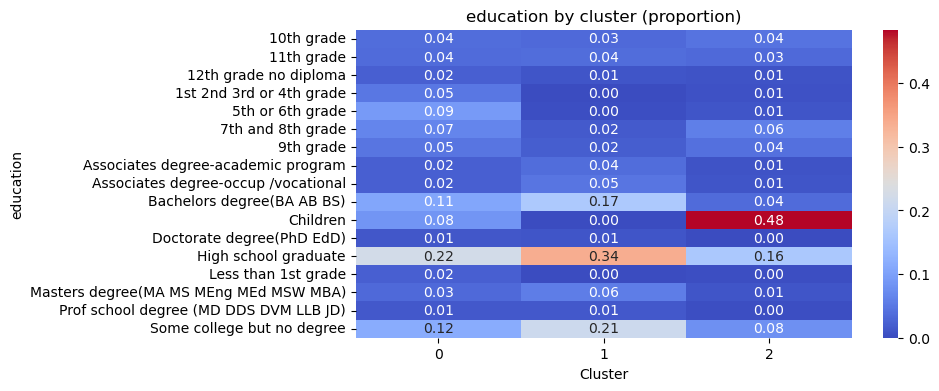

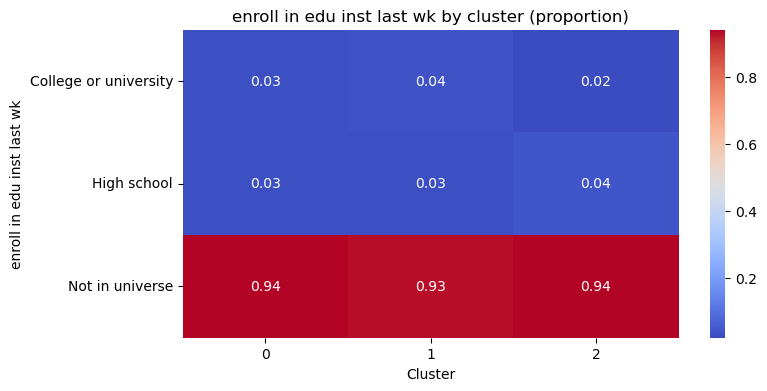

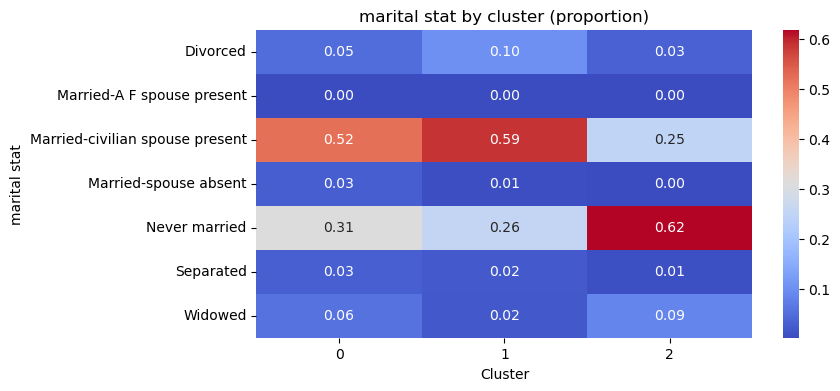

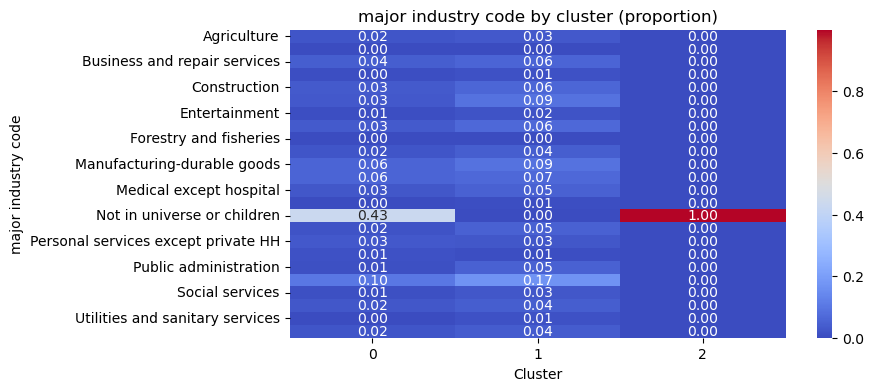

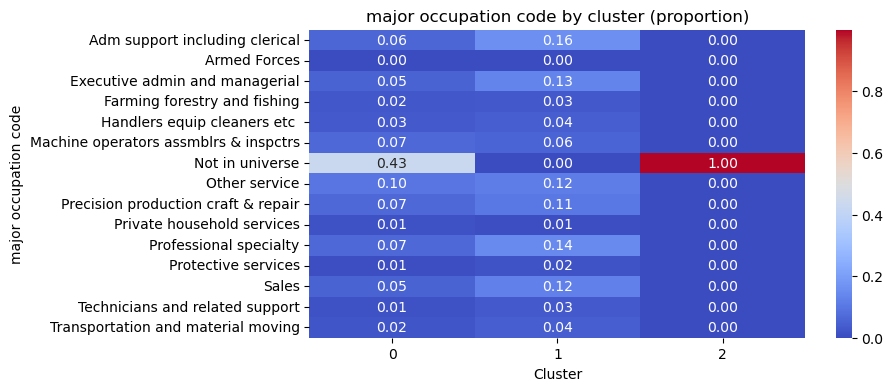

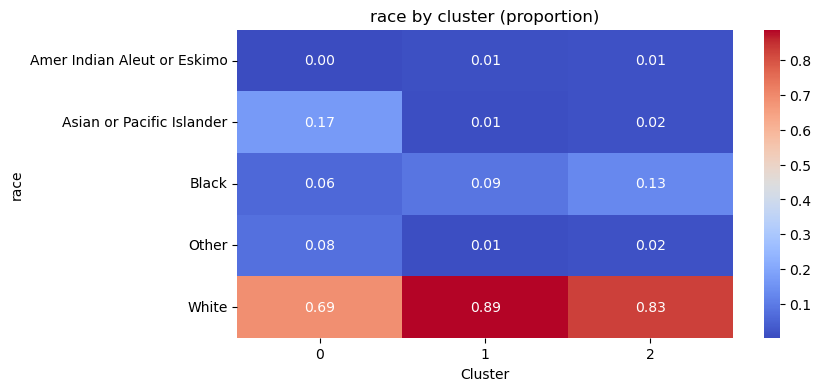

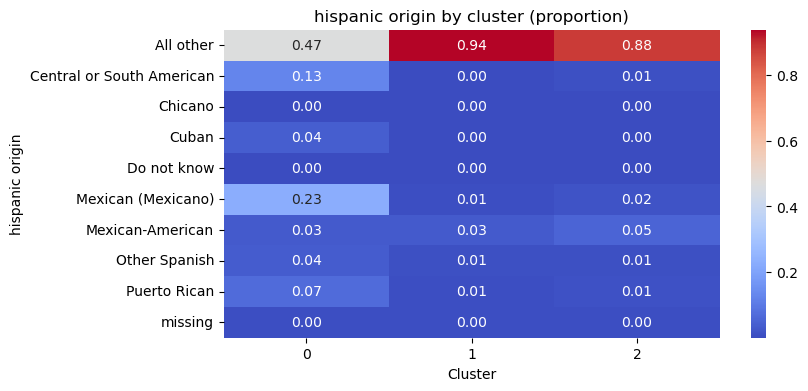

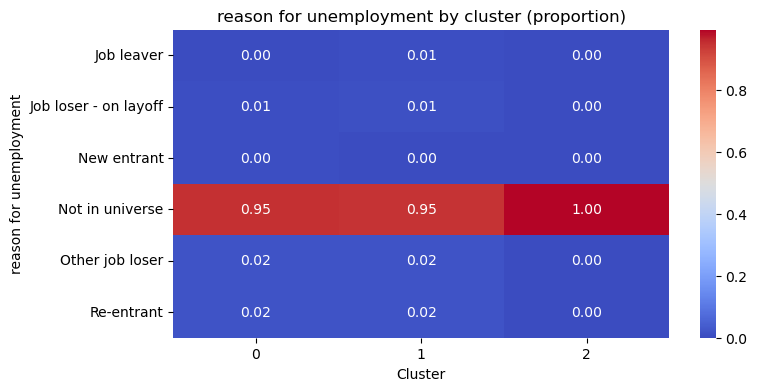

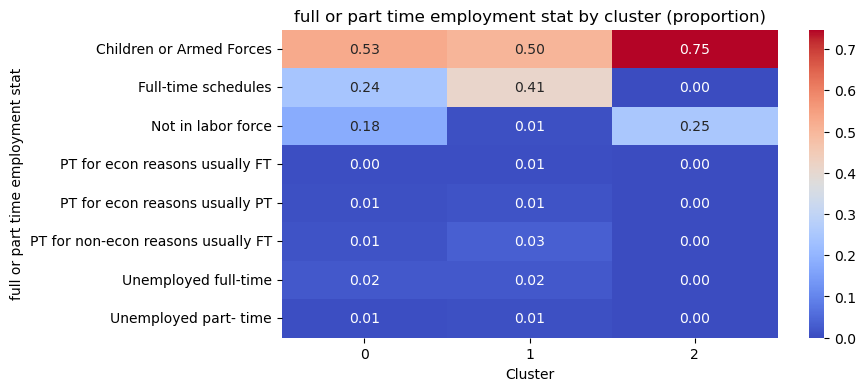

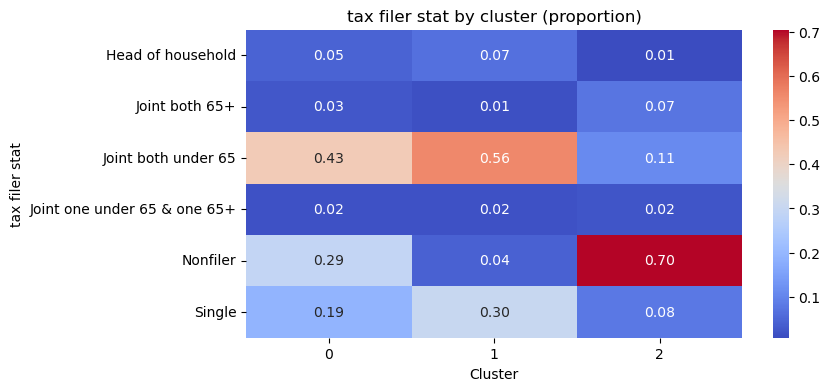

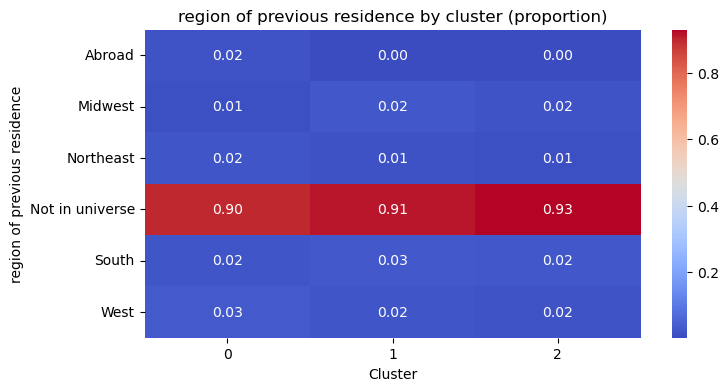

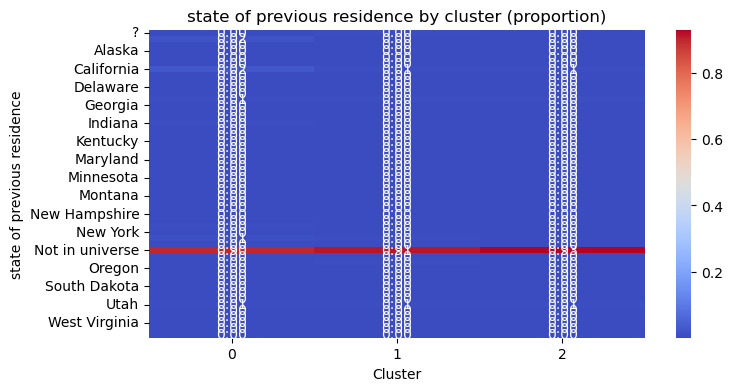

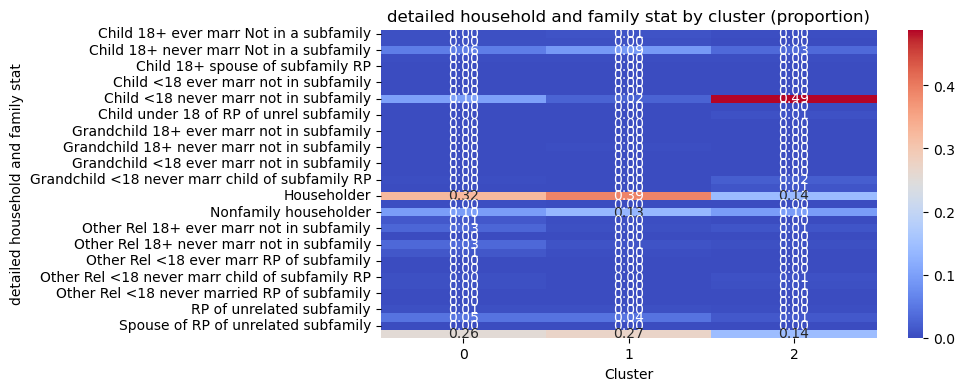

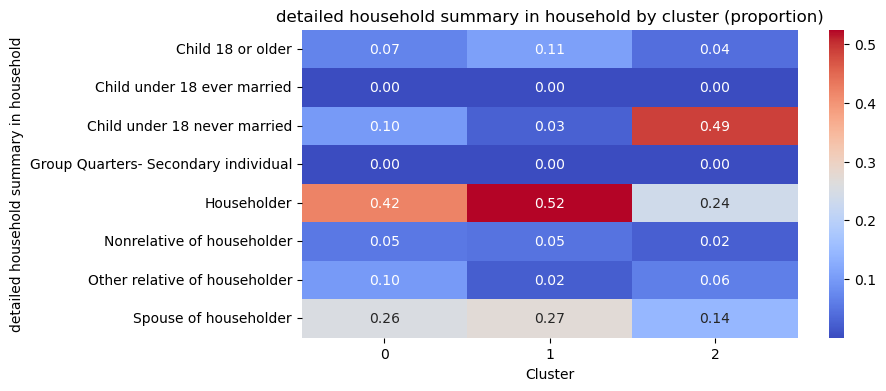

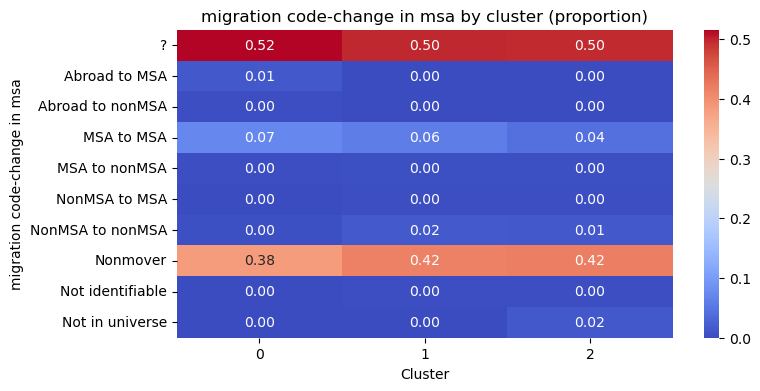

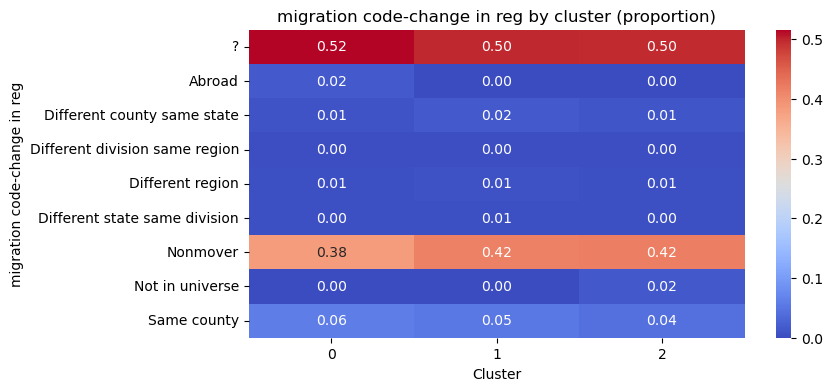

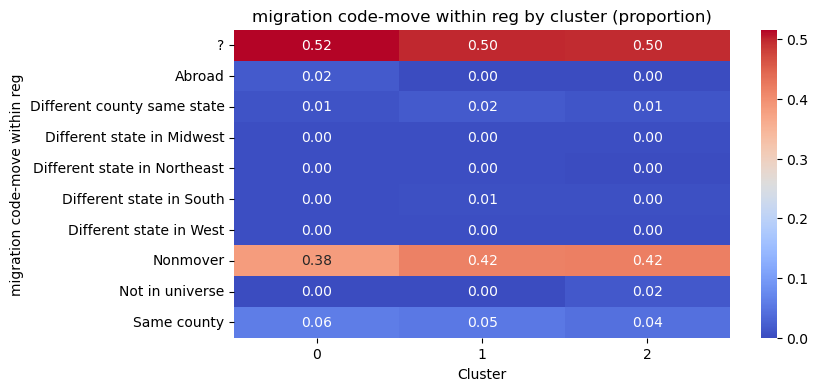

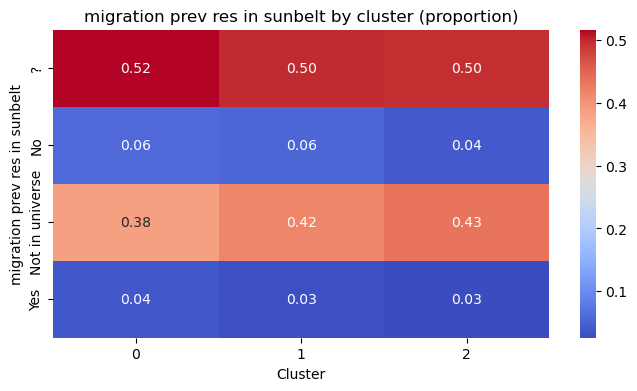

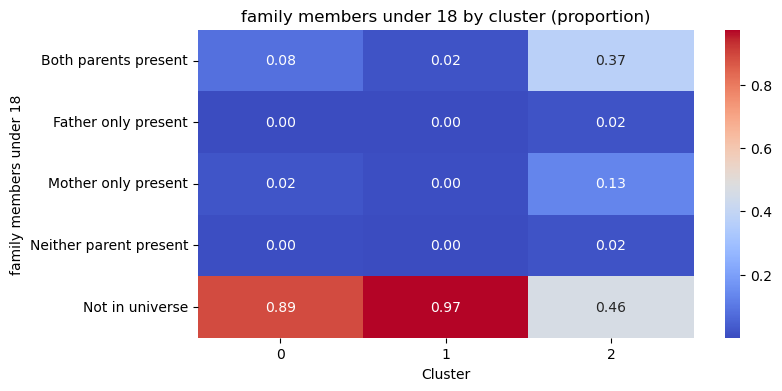

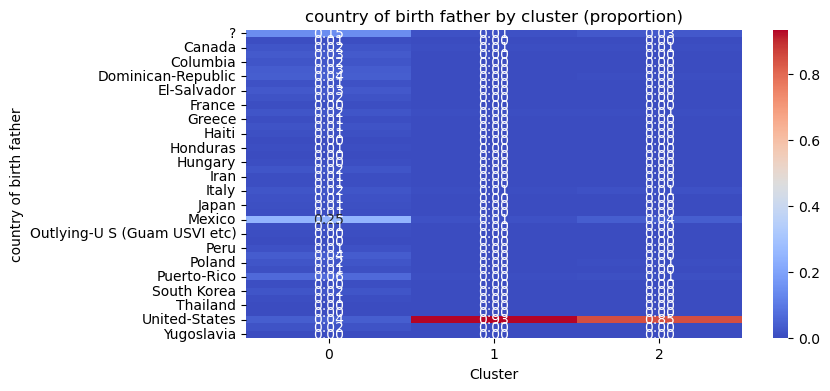

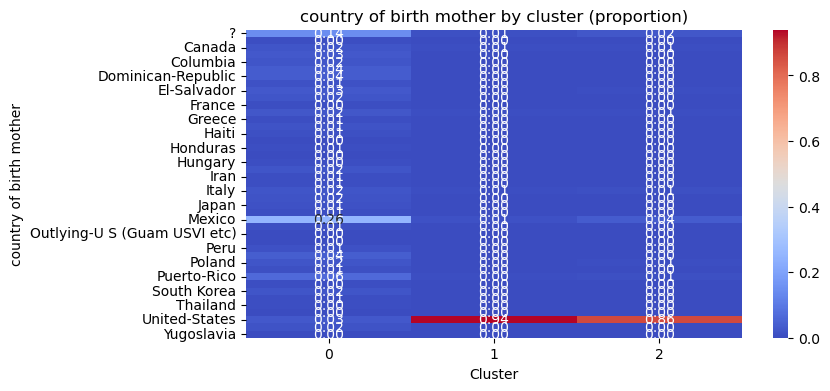

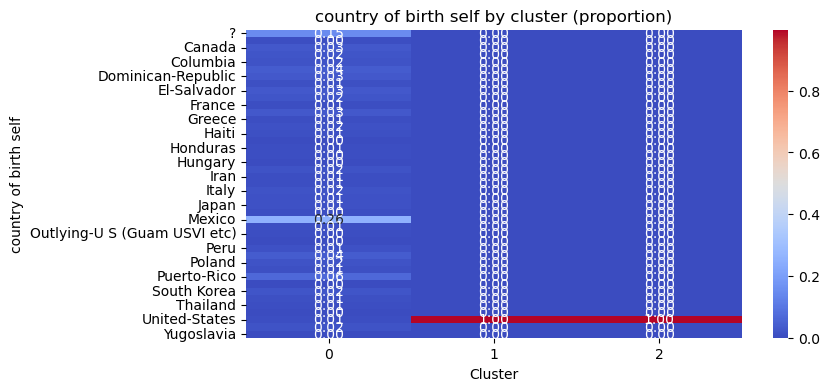

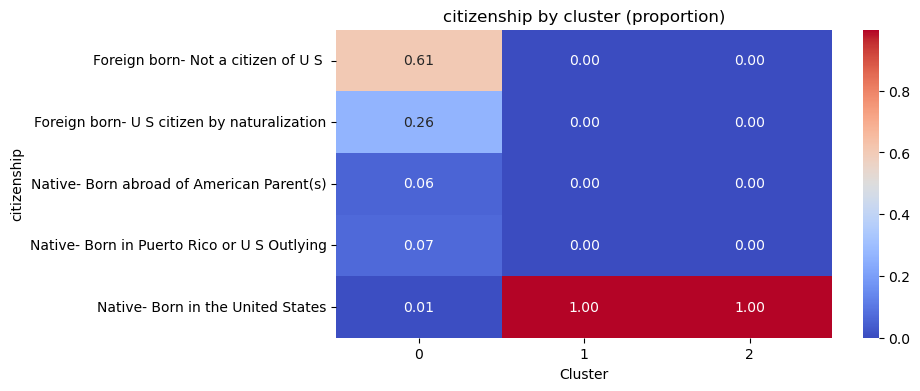

In [97]:
import seaborn as sns
for feature in categorical:
    ct = pd.crosstab(X[feature], X['cluster'], normalize='columns')
    plt.figure(figsize=(8,4))
    sns.heatmap(ct, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title(f'{feature} by cluster (proportion)')
    plt.ylabel(feature)
    plt.xlabel('Cluster')
    plt.show()